<a href="https://colab.research.google.com/github/milleau98/2026-gig-data-analysis/blob/main/notebooks/data-analyses/correlation_analyses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from pathlib import Path

## Merging Datasets


In [2]:
parent_dir = Path.cwd().parent.parent

In [3]:
import pandas as pd

# pull in stock price for both gig and S&P 500 yfinance data
gig_stock_df_monthly = pd.read_csv(os.path.join(parent_dir,'data','yfinance','gig_yfinance_monthly.csv'), parse_dates=['Date'])
sp500_stock_df_monthly = pd.read_csv(os.path.join(parent_dir,'data','yfinance','sp500_yfinance_monthly.csv'), parse_dates=['Date'])

# combine gig and sp500 stock data
stock_df_monthly = pd.concat([gig_stock_df_monthly, sp500_stock_df_monthly])

# pull in Google trend data
google_df_monthly = pd.read_csv(os.path.join(parent_dir,'data','google_trends','google_trends_monthly.csv'), parse_dates=['date'])

# pull in FRED data
fred_df_monthly = pd.read_csv(os.path.join(parent_dir,'data','fred','fred_monthly_data.csv'), parse_dates=['date'])

In [4]:
# make Google trend dataset long to match format of other datasets in order to merge

google_df_monthly_long = google_df_monthly.melt(
    id_vars=['year', 'month'],
    value_vars= ['Uber','Lyft','DoorDash','Instacart','Fiverr','Upwork', 'Nu skin', 'USANA', 'side hustle','gig','Herbalife','Primerica','Etsy', 'Shopify', 'Udemy'],
    var_name = 'company',
    value_name = 'SearchInterest'
)


In [5]:
# rename columns to match across datasets
gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Year': 'year'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Year': 'year'})

stock_df_monthly = stock_df_monthly.rename(columns={'Year':'year', 'Month':'month', 'Company':'company'})

gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Month': 'month'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Month': 'month'})

# only keep necessary columns before merging
monthly_stock_cols = ['year', 'month', 'company','Close']
monthly_fred_cols = ['year', 'month', 'cpi_inflation_data_annual','unemployment_data_monthly', 'cpi_data_monthly', 'rec_smooth_prob_data_monthly', 'rec_nber_data_monthly',
                     'labor_force_participation_data_monthly', 'job_hires_data_monthly', 'gdp_real_data_quarterly', 'm2_real_data_monthly', 'interest_rate_fedfunds_data_monthly',
                     'consumer_sentiment_data_monthly']
monthly_google_cols = ['year', 'month', 'company','SearchInterest']

stock_df_monthly = stock_df_monthly[monthly_stock_cols]

fred_df_monthly = fred_df_monthly[monthly_fred_cols]

google_df_monthly_long = google_df_monthly_long[monthly_google_cols]

# merge all datasets together based on company, year, and month
merged_df_monthly = (
    stock_df_monthly
    .merge(google_df_monthly_long, on=['year','company','month'], how='left')
    .merge(fred_df_monthly, on=['year','month'], how='left'))

# create target variable = close/cpi_data_monthly in order to utilize for correlation analysis

merged_df_monthly['target'] = merged_df_monthly['Close'] / merged_df_monthly['cpi_data_monthly']

merged_df_monthly.head(75)

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,labor_force_participation_data_monthly,job_hires_data_monthly,gdp_real_data_quarterly,m2_real_data_monthly,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target
0,2018,10,Upwork,19.200001,2.0,2.442583,3.8,252.772,0.46,0.0,62.9,5562.0,20304.874,5640.1,2.19,98.6,0.075958
1,2018,11,Upwork,18.629999,1.0,2.442583,3.8,252.594,0.40,0.0,62.9,5461.0,20304.874,5654.4,2.20,97.5,0.073755
2,2018,12,Upwork,18.110001,1.0,2.442583,3.9,252.767,0.68,0.0,63.0,5400.0,20304.874,5691.7,2.27,98.3,0.071647
3,2019,1,Upwork,19.309999,2.0,1.812210,4.0,252.561,1.76,0.0,63.1,5411.0,20431.641,5725.2,2.40,91.2,0.076457
4,2019,2,Upwork,23.690001,2.0,1.812210,3.8,253.319,1.82,0.0,63.1,5345.0,20431.641,5726.5,2.40,93.8,0.093518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2024,8,Upwork,9.640000,3.0,2.949525,4.2,314.062,0.60,0.0,62.7,4846.0,23478.570,6745.7,5.33,67.9,0.030695
71,2024,9,Upwork,10.450000,2.0,2.949525,4.1,314.732,0.68,0.0,62.7,5071.0,23478.570,6757.7,5.13,70.1,0.033203
72,2024,10,Upwork,13.560000,2.0,2.949525,4.1,315.631,0.50,0.0,62.5,4866.0,23586.542,6758.2,4.83,70.5,0.042962
73,2024,11,Upwork,16.969999,2.0,2.949525,4.2,316.528,0.34,0.0,62.4,4820.0,23586.542,6777.2,4.64,71.8,0.053613


In [6]:
# Create transformed variables so that we don't create spurious correlations

df = merged_df_monthly.sort_values(['company','year','month'])

# Stock returns
df['Return'] = df.groupby('company')['Close'].pct_change()
df['Target_change'] = df.groupby('company')['target'].pct_change()

# Search interest change
df['Search_change'] = df.groupby('company')['SearchInterest'].diff()

# Macro changes
df['Inflation_change'] = df['cpi_data_monthly'].pct_change()
df['Unemployment_change'] = df['unemployment_data_monthly'].diff()
df['InterestRate_change'] = df['interest_rate_fedfunds_data_monthly'].diff()
df['ConsumerSentiment_change'] = df['consumer_sentiment_data_monthly'].diff()

df.head()

C:\Users\mlxfl\AppData\Local\Temp\ipykernel_14596\167519435.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Target_change'] = df.groupby('company')['target'].pct_change()
C:\Users\mlxfl\AppData\Local\Temp\ipykernel_14596\167519435.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Inflation_change'] = df['cpi_data_monthly'].pct_change()


,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change
1526,2009,1,3M,26.811335,NaN,-0.355546,7.8,211.933,99.74,1.0,...,0.15,61.2,0.126509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1527,2009,2,3M,22.905647,NaN,-0.355546,8.3,212.705,99.36,1.0,...,0.22,56.3,0.107687,-0.145673,-0.148774,NaN,0.003643,0.5,0.07,-4.9
1528,2009,3,3M,25.052105,NaN,-0.355546,8.7,212.495,99.34,1.0,...,0.18,57.3,0.117895,0.093709,0.094790,NaN,-0.000987,0.4,-0.04,1.0
1529,2009,4,3M,29.022554,NaN,-0.355546,9.0,212.709,96.24,1.0,...,0.15,65.1,0.136443,0.158488,0.157322,NaN,0.001007,0.3,-0.03,7.8
1530,2009,5,3M,29.021479,NaN,-0.355546,9.4,213.022,87.06,1.0,...,0.18,68.7,0.136237,-0.000037,-0.001506,NaN,0.001471,0.4,0.03,3.6


In [7]:
# Create CompanyType Column to split gig/MLM and SP500 Companies
gig_companies = ['Uber','Lyft','DoorDash','Instacart','Fiverr','Upwork',
                 'Etsy','Shopify','Udemy',
                 ]

mlm_companies = ['Herbalife','Primerica','Tupperware','Avon','Nu skin', 'USANA']

def company_type(company):
    if company in gig_companies:
        return 'Gig'
    elif company in mlm_companies:
        return 'MLM'
    else:
        return 'SP500'

df['CompanyType'] = df['company'].apply(company_type)


df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType
1526,2009,1,3M,26.811335,NaN,-0.355546,7.8,211.933,99.74,1.0,...,61.2,0.126509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SP500
1527,2009,2,3M,22.905647,NaN,-0.355546,8.3,212.705,99.36,1.0,...,56.3,0.107687,-0.145673,-0.148774,NaN,0.003643,0.5,0.07,-4.9,SP500
1528,2009,3,3M,25.052105,NaN,-0.355546,8.7,212.495,99.34,1.0,...,57.3,0.117895,0.093709,0.094790,NaN,-0.000987,0.4,-0.04,1.0,SP500
1529,2009,4,3M,29.022554,NaN,-0.355546,9.0,212.709,96.24,1.0,...,65.1,0.136443,0.158488,0.157322,NaN,0.001007,0.3,-0.03,7.8,SP500
1530,2009,5,3M,29.021479,NaN,-0.355546,9.4,213.022,87.06,1.0,...,68.7,0.136237,-0.000037,-0.001506,NaN,0.001471,0.4,0.03,3.6,SP500


In [8]:
import scipy.stats as stats

# Define economic stress periods

# Step 1: get one row per month (not one per company-month)
# FRED variables are the same across all companies for a given month

macro_ts = (df[['year', 'month', 'unemployment_data_monthly',
        'cpi_data_monthly', 'consumer_sentiment_data_monthly']]
    .drop_duplicates(subset=['year', 'month'])
    .sort_values(['year', 'month'])
    .reset_index(drop=True))

# Step 2: compute z-scores on the true monthly time series relative to 2010-2025
macro_ts['unemployment_z'] = stats.zscore(macro_ts['unemployment_data_monthly'].ffill())
macro_ts['cpi_z'] = stats.zscore(macro_ts['cpi_data_monthly'].ffill())
macro_ts['consumer_sentiment_z'] = stats.zscore(macro_ts['consumer_sentiment_data_monthly'].ffill())

# Step 3: define stress based on z-score threshold
macro_ts['EconomicStress'] = (
    (macro_ts['unemployment_z'] > 1) |      # high unemployment
    (macro_ts['cpi_z'] > 1) |               # high inflation
    (macro_ts['consumer_sentiment_z'] < -1) # low consumer sentiment
)

# Step 4: merge stress flags back into full df
# every company row for a given month gets the same stress label

df = df.merge(
    macro_ts[['year', 'month', 'unemployment_z', 'cpi_z',
              'consumer_sentiment_z', 'EconomicStress']],
    on=['year', 'month'],
    how='left'
)

df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType,unemployment_z,cpi_z,consumer_sentiment_z,EconomicStress
0,2009,1,3M,26.811335,NaN,-0.355546,7.8,211.933,99.74,1.0,...,NaN,NaN,NaN,NaN,NaN,SP500,0.822972,-1.339586,-1.263941,True
1,2009,2,3M,22.905647,NaN,-0.355546,8.3,212.705,99.36,1.0,...,NaN,0.003643,0.5,0.07,-4.9,SP500,1.041006,-1.316015,-1.621530,True
2,2009,3,3M,25.052105,NaN,-0.355546,8.7,212.495,99.34,1.0,...,NaN,-0.000987,0.4,-0.04,1.0,SP500,1.215433,-1.322426,-1.548553,True
3,2009,4,3M,29.022554,NaN,-0.355546,9.0,212.709,96.24,1.0,...,NaN,0.001007,0.3,-0.03,7.8,SP500,1.346253,-1.315892,-0.979329,True
4,2009,5,3M,29.021479,NaN,-0.355546,9.4,213.022,87.06,1.0,...,NaN,0.001471,0.4,0.03,3.6,SP500,1.520681,-1.306336,-0.716610,True


# Correlation Matrix

In [9]:
# Compute summary statistics by CompanyType and EconomicStress

summary_table = df.groupby(['CompanyType','EconomicStress']).agg({
    'Return':'mean',
    'Target_change':'mean',
    'Search_change':'mean'
}).reset_index()

print(summary_table)

  CompanyType  EconomicStress    Return  Target_change  Search_change
0         Gig           False  0.013424       0.010686      -0.143340
1         Gig            True  0.017153       0.014674       0.078439
2         MLM           False  0.013337       0.011465      -0.008772
3         MLM            True  0.013320       0.010760      -0.008772
4       SP500           False  0.013580       0.011681            NaN
5       SP500            True  0.019696       0.017166            NaN


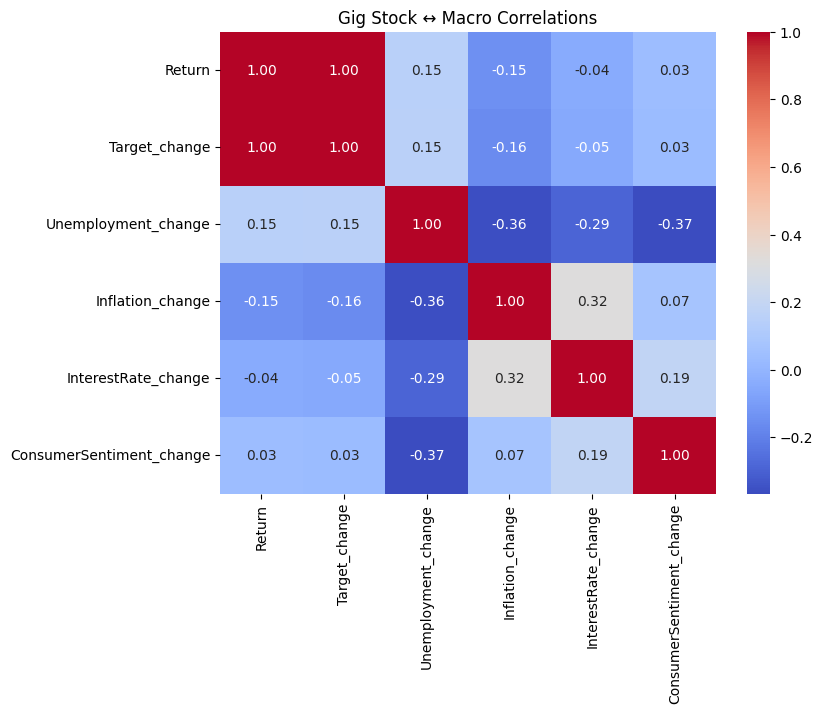

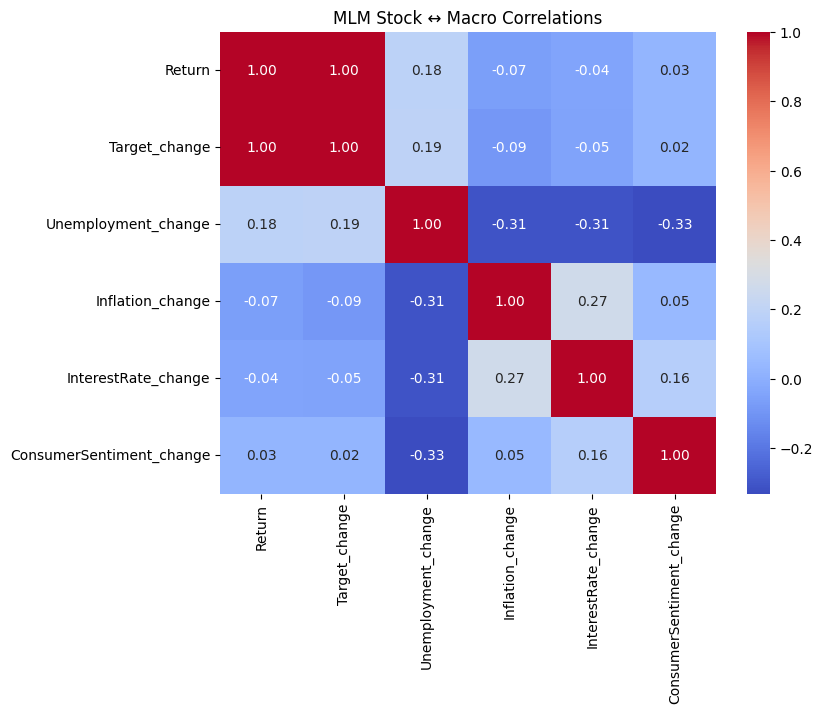

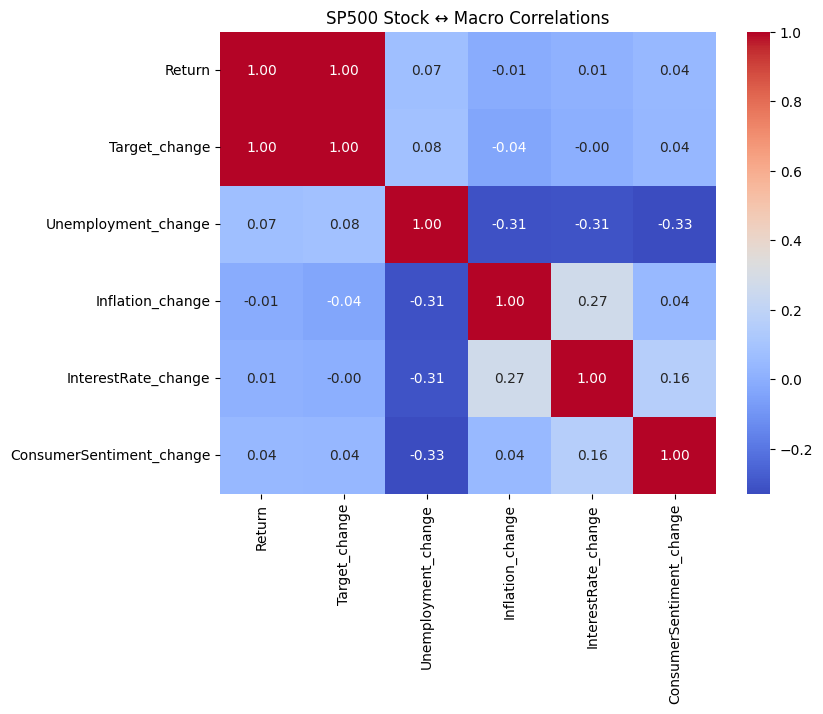

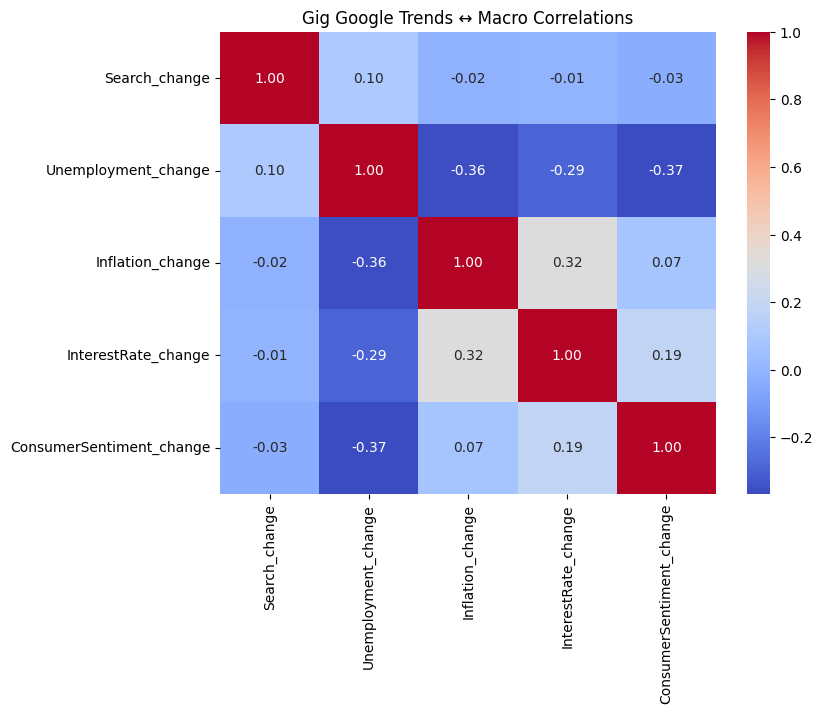

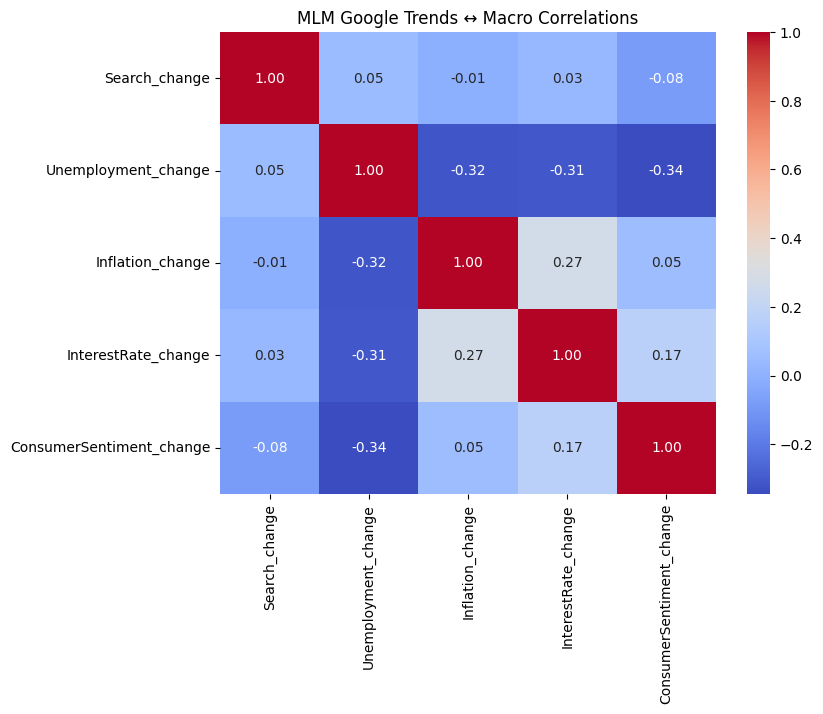

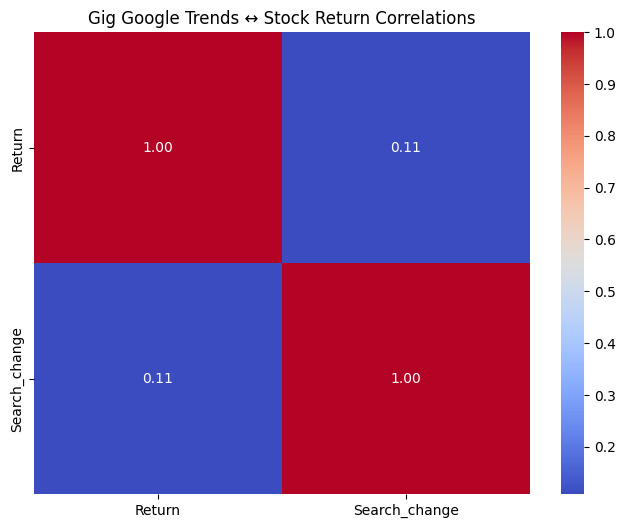

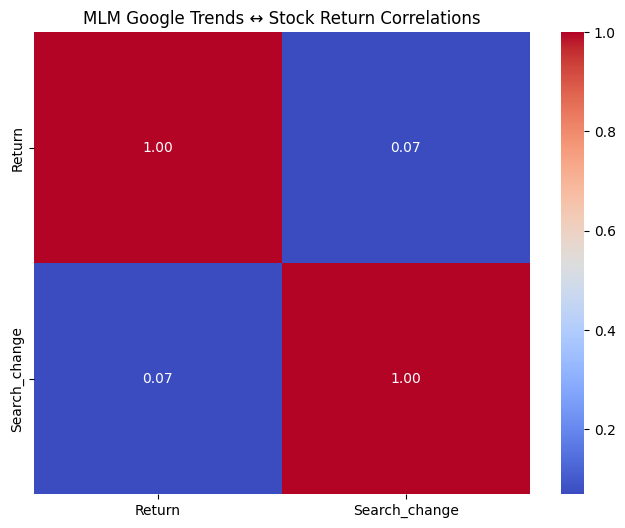

In [10]:
# Define correlation matrices
import matplotlib.pyplot as plt
import seaborn as sns
cols_stock_macro = [
    'Return',
    'Target_change',
    'Unemployment_change',
    'Inflation_change',
    'InterestRate_change',
    'ConsumerSentiment_change'
]

cols_trends_macro = [
    'Search_change',
    'Unemployment_change',
    'Inflation_change',
    'InterestRate_change',
    'ConsumerSentiment_change'
]

cols_trends_stock = [
    'Return',
    'Search_change'
]

# Function to plot heatmap
def plot_corr_matrix(df_corr, title):
    plt.figure(figsize=(8,6))
    sns.heatmap(df_corr, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title(title)
    plt.show()

# Macro ↔ Stock returns correlations

for g in ['Gig','MLM','SP500']:
    temp = df[df['CompanyType']==g]
    corr = temp[cols_stock_macro].dropna().corr()
    plot_corr_matrix(corr, f"{g} Stock ↔ Macro Correlations")

# Macro ↔ Google Trends correlations

for g in ['Gig','MLM']:
    temp = df[df['CompanyType']==g]
    corr = temp[cols_trends_macro].dropna().corr()
    plot_corr_matrix(corr, f"{g} Google Trends ↔ Macro Correlations")


# Google Trends ↔ Stock returns correlations

for g in ['Gig','MLM']:
    temp = df[df['CompanyType']==g]
    corr = temp[cols_trends_stock].dropna().corr()
    plot_corr_matrix(corr, f"{g} Google Trends ↔ Stock Return Correlations")


In [11]:
# create industry dataframes by splitting out merged dataset with all columns
gig_df = df[df['CompanyType'] == 'Gig']
MLM_df = df[df['CompanyType'] == 'MLM']
SP500_df = df[df['CompanyType'] == 'SP500']

# Economic Stress Analysis

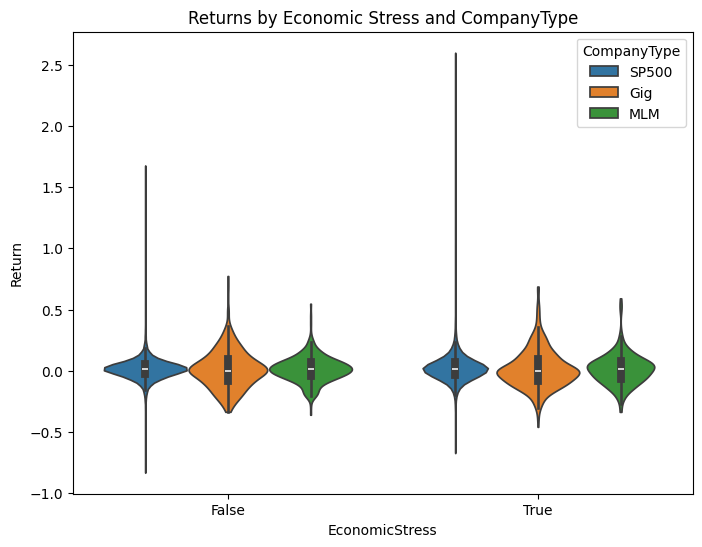

In [12]:
# Violin plot: Return distribution by EconomicStress

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.violinplot(x='EconomicStress', y='Return', hue='CompanyType', data=df, cut=0)
plt.title("Returns by Economic Stress and CompanyType")
plt.show()

In [13]:
from scipy.stats import ttest_ind

# T-tests: Stress vs. Non-Stress Returns

for g in ['Gig','MLM','SP500']:
    stress = df[(df['CompanyType']==g) & (df['EconomicStress']==True)]['Return'].dropna()
    nonstress = df[(df['CompanyType']==g) & (df['EconomicStress']==False)]['Return'].dropna()
    t_stat, p_val = ttest_ind(stress, nonstress)
    print(f"{g} Stress vs Non-Stress Returns: t={t_stat:.2f}, p={p_val:.4f}")


Gig Stress vs Non-Stress Returns: t=0.33, p=0.7440
MLM Stress vs Non-Stress Returns: t=-0.00, p=0.9985
SP500 Stress vs Non-Stress Returns: t=10.38, p=0.0000


# CCF: Lag Analysis - Search Interest, Volatility, & Stock Price

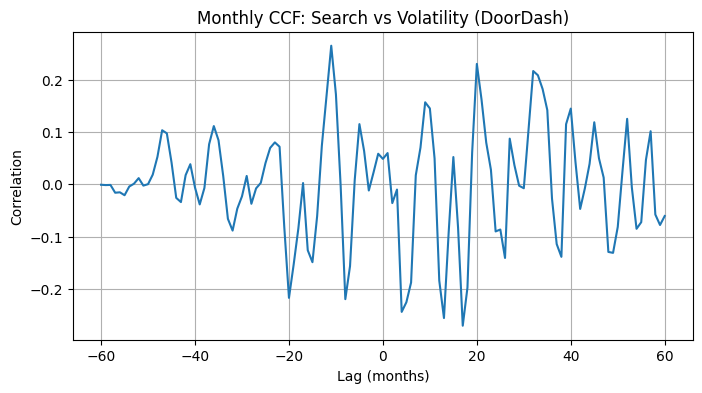

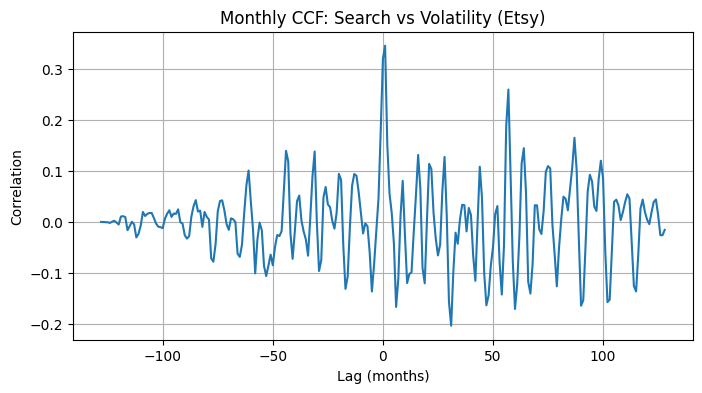

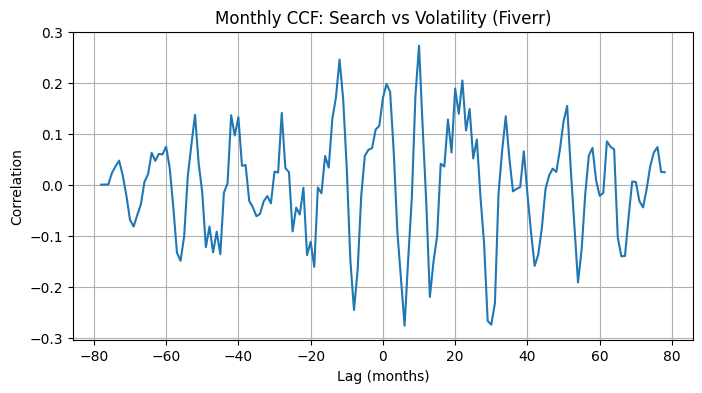

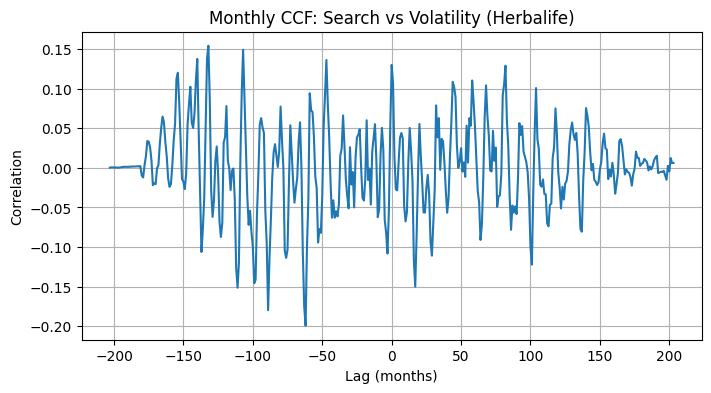

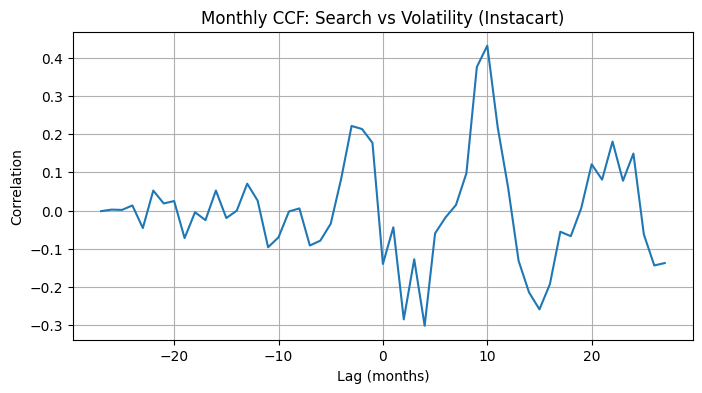

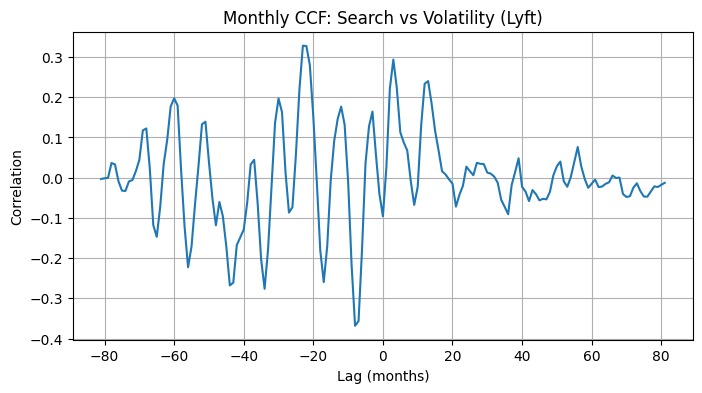

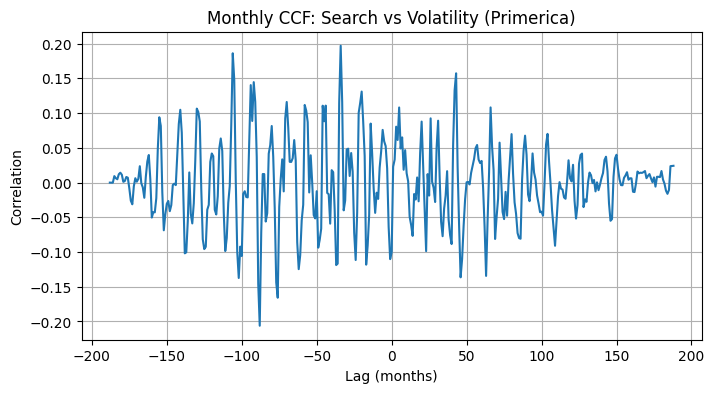

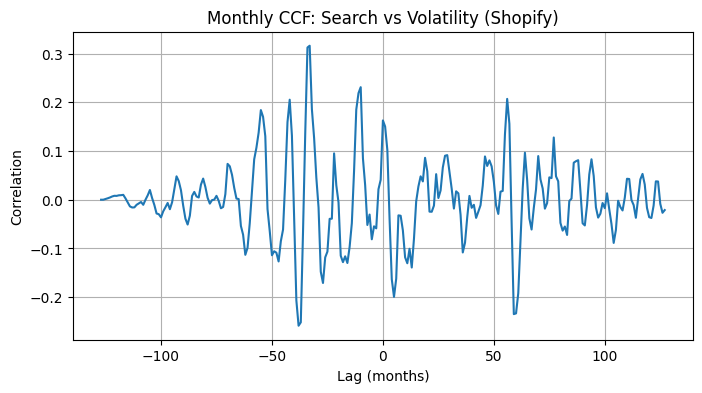

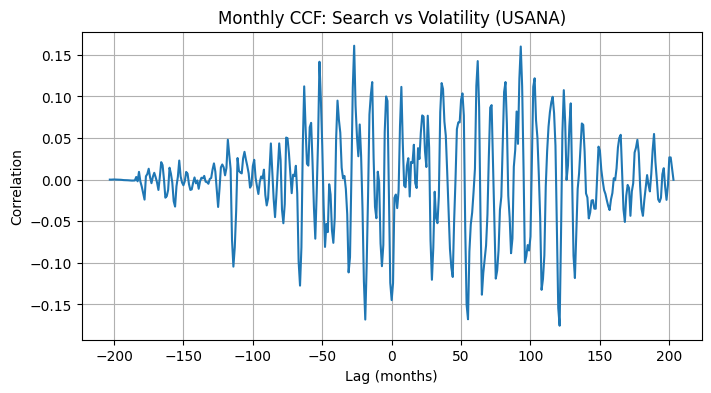

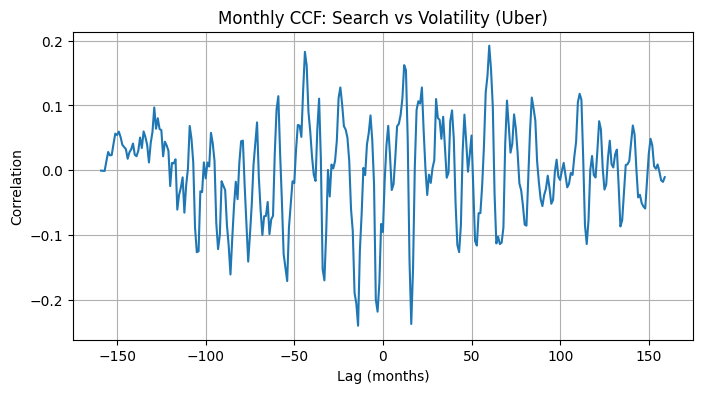

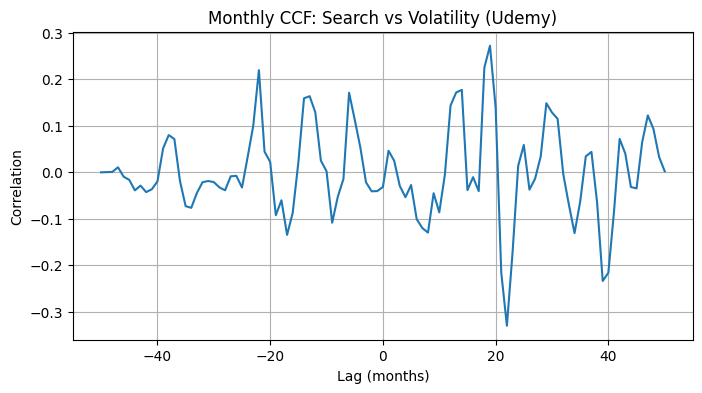

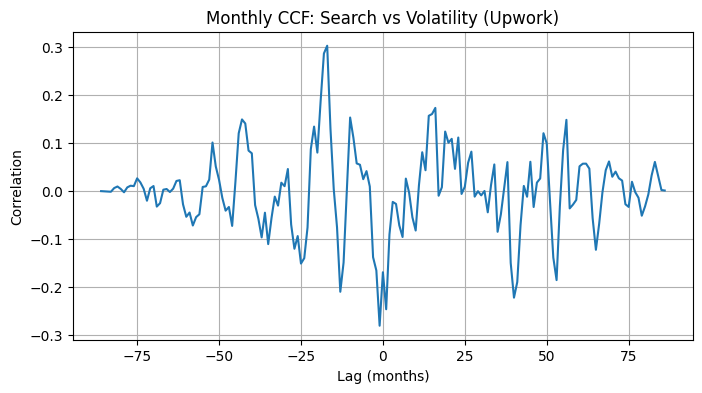

In [14]:
from statsmodels.tsa.stattools import ccf
import numpy as np

# Volatility

# Normalized CCF function
def normalized_ccf(x, y):
  x = (x - np.mean(x)) / np.std(x)
  y = (y - np.mean(y)) / np.std(y)
  return np.correlate(x, y, mode='full') / len(x)

companies = df['company'].unique()

for c in companies:
    temp = df[df['company'] == c].copy()
    temp = temp.sort_values(['year', 'month'])
    temp['date'] = pd.to_datetime(temp[['year','month']].assign(day=1))
    temp = temp.set_index('date')

    if temp['SearchInterest'].notna().sum() > 10:
        # Smoothed monthly change in search interest
        x = temp['SearchInterest'].diff().rolling(3).mean().fillna(0)
        # 3-month rolling volatility of returns
        y = temp['Close'].pct_change().rolling(3).std().fillna(0)

        ccf_vals = normalized_ccf(x, y)
        lags = np.arange(-(len(x)-1), len(x))  # label lags in months

        plt.figure(figsize=(8,4))
        plt.plot(lags, ccf_vals)
        plt.title(f'Monthly CCF: Search vs Volatility ({c})')
        plt.xlabel('Lag (months)')
        plt.ylabel('Correlation')
        plt.grid(True)
        plt.show()

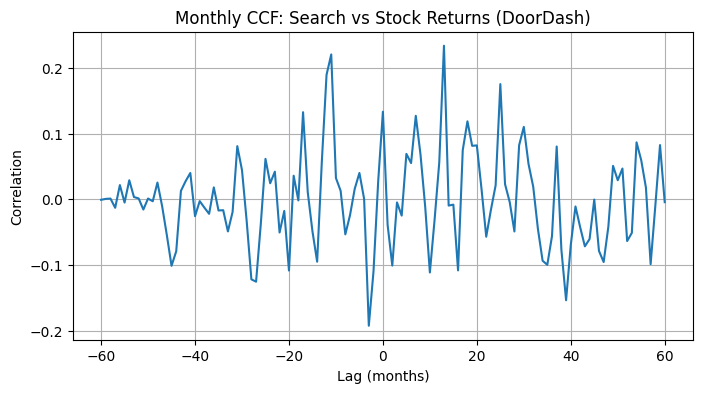

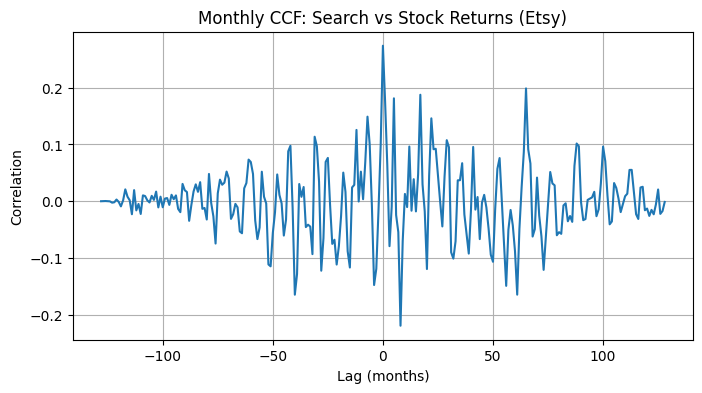

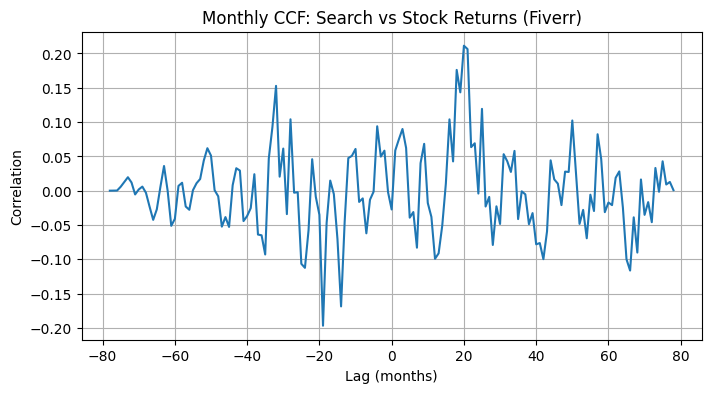

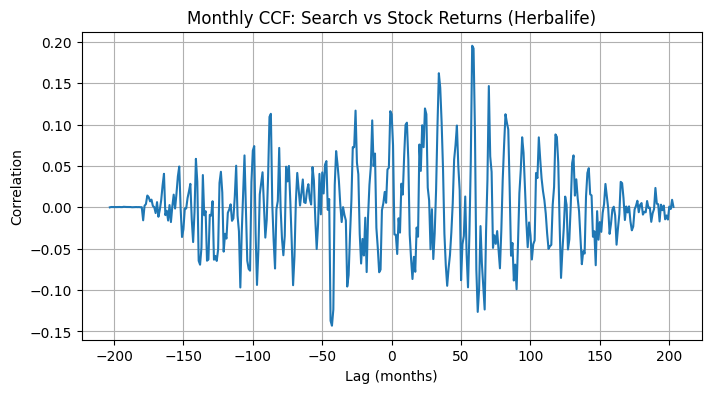

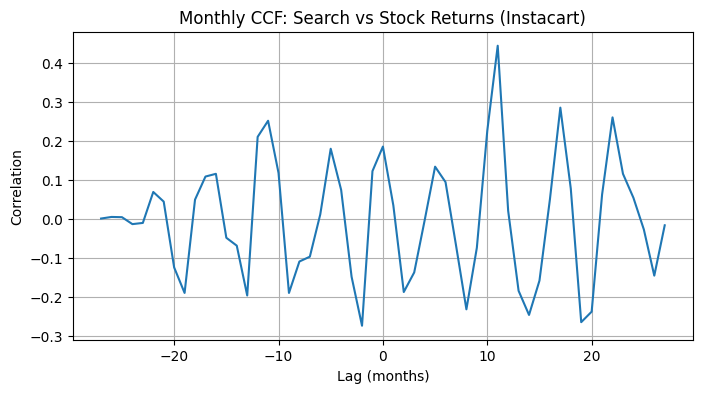

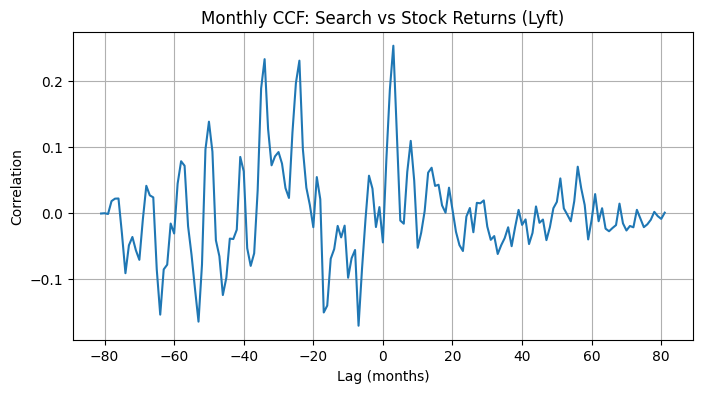

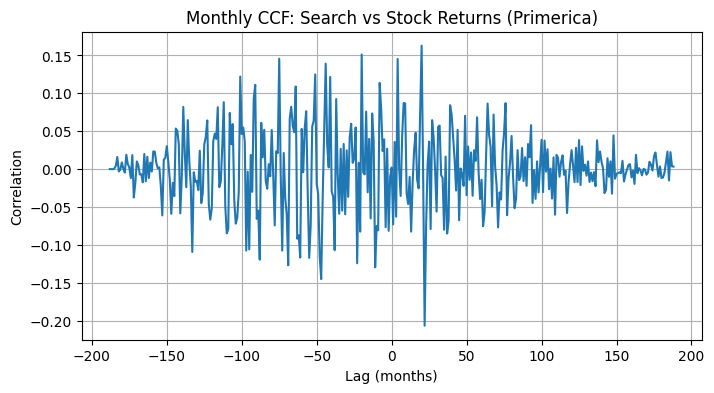

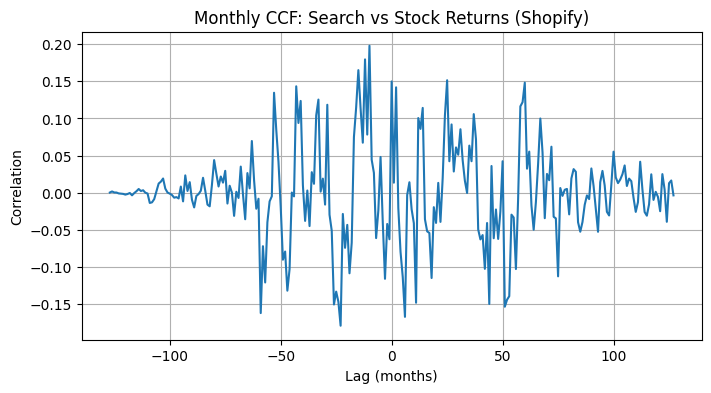

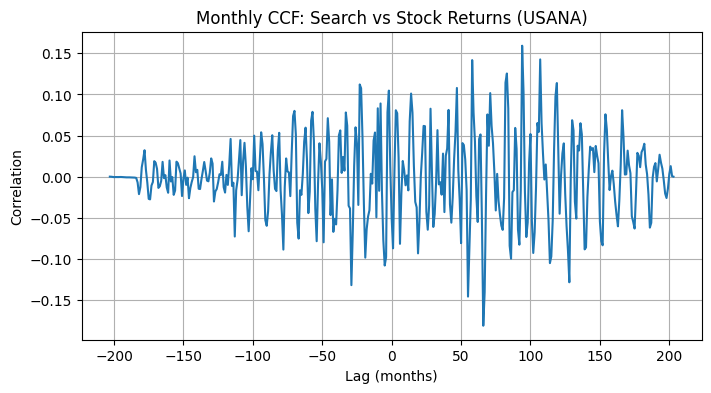

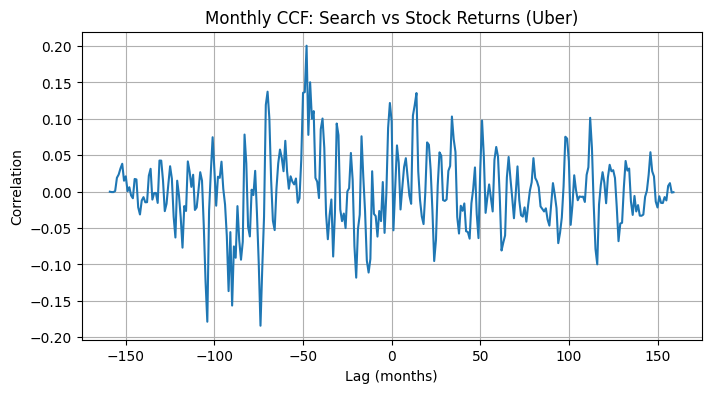

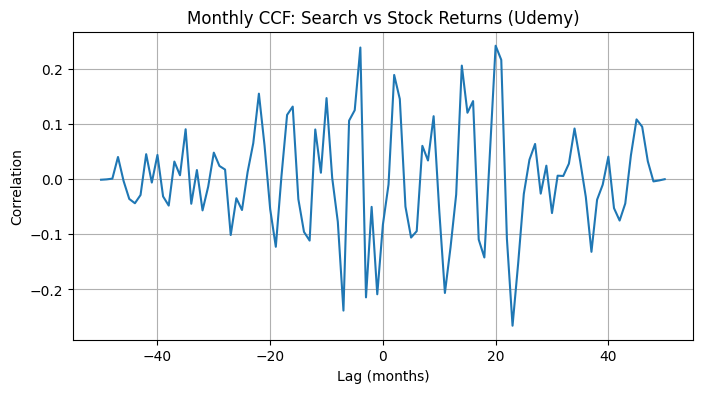

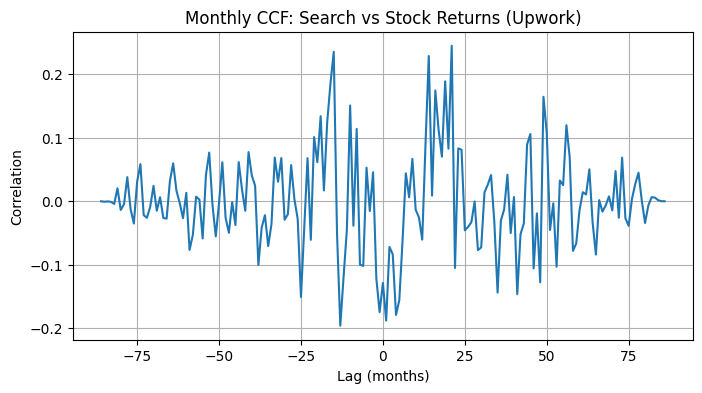

In [15]:
# Stock Returns

for c in companies:
    temp = df[df['company'] == c].copy()
    temp = temp.sort_values(['year', 'month'])
    temp['date'] = pd.to_datetime(temp[['year','month']].assign(day=1))
    temp = temp.set_index('date')

    if temp['SearchInterest'].notna().sum() > 10:
        # Smoothed monthly change in search interest
        x = temp['SearchInterest'].diff().rolling(3).mean().fillna(0)
        # 3-month rolling volatility of returns
        y = temp['Close'].pct_change().fillna(0)

        ccf_vals = normalized_ccf(x, y)
        lags = np.arange(-(len(x)-1), len(x))  # label lags in months

        plt.figure(figsize=(8,4))
        plt.plot(lags, ccf_vals)
        plt.title(f'Monthly CCF: Search vs Stock Returns ({c})')
        plt.xlabel('Lag (months)')
        plt.ylabel('Correlation')
        plt.grid(True)
        plt.show()

In [16]:
# Lagged correlations: Search_change vs Return
# summary table to show lag correlations in months 1 through 3

lags = [1, 2, 3]  # lags in months
lagged_corrs = []

companies = df['company'].unique()

for c in companies:
    temp = df[df['company']==c].sort_values(['year','month']).copy()
    temp = temp.reset_index(drop=True)

    # ensure enough non-NaN values
    if temp['Search_change'].notna().sum() > max(lags)+2 and temp['Return'].notna().sum() > max(lags)+2:
        for lag in lags:
            # Shift Search_change forward by lag months to see if trends "lead" returns
            temp[f'Search_lead_{lag}'] = temp['Search_change'].shift(lag)
            corr_val = temp[['Return', f'Search_lead_{lag}']].dropna().corr().iloc[0,1]
            lagged_corrs.append({
                'company': c,
                'lag_months': lag,
                'lagged_corr': corr_val
            })

# convert to DataFrame for easy viewing
lagged_corr_df = pd.DataFrame(lagged_corrs)

# display lagged correlations
print(lagged_corr_df.head(20))

# add: summary by CompanyType
lagged_corr_df = lagged_corr_df.merge(df[['company','CompanyType']].drop_duplicates(), on='company', how='left')

summary_lagged = lagged_corr_df.groupby(['CompanyType','lag_months'])['lagged_corr'].mean().reset_index()
print(summary_lagged)

      company  lag_months  lagged_corr
0    DoorDash           1     0.111135
1    DoorDash           2     0.154310
2    DoorDash           3    -0.214044
3        Etsy           1     0.064961
4        Etsy           2     0.071475
5        Etsy           3     0.015570
6      Fiverr           1     0.035040
7      Fiverr           2    -0.070001
8      Fiverr           3     0.031241
9   Herbalife           1     0.127237
10  Herbalife           2    -0.026862
11  Herbalife           3     0.092300
12  Instacart           1     0.234953
13  Instacart           2     0.180751
14  Instacart           3    -0.122078
15       Lyft           1     0.038718
16       Lyft           2    -0.110184
17       Lyft           3     0.074254
18  Primerica           1     0.018446
19  Primerica           2    -0.097589
  CompanyType  lag_months  lagged_corr
0         Gig           1     0.019993
1         Gig           2     0.044662
2         Gig           3    -0.049250
3         MLM           1

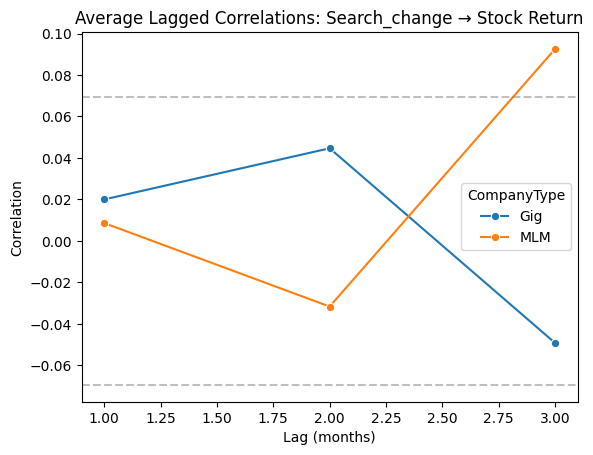

In [17]:
# plot lagged results for gig and MLM companies using Google trend data and stock return data
sns.lineplot(data=summary_lagged, x='lag_months', y='lagged_corr', hue='CompanyType', marker='o')
plt.title("Average Lagged Correlations: Search_change → Stock Return")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation")

# add confidence interval to reduce noise
n = df[df['CompanyType'] == 'Gig']['Return'].dropna().shape[0]
ci = 1.96 / np.sqrt(n)
plt.axhline(ci, color='gray', linestyle='--', alpha=0.5, label='95% CI')
plt.axhline(-ci, color='gray', linestyle='--', alpha=0.5)
plt.show()

# Industry CCFs - Understanding Lags by Industry


In [18]:
# create industry dataframes including all of the same information

gig_ts = gig_df.groupby(['year','month']).agg({
    'Return': 'mean',
    'Unemployment_change': 'mean',
    'Inflation_change': 'mean',
    'Search_change': 'mean'
}).reset_index()

mlm_ts = MLM_df.groupby(['year','month']).agg({
    'Return': 'mean',
    'Unemployment_change': 'mean',
    'Inflation_change': 'mean',
    'Search_change': 'mean'
}).reset_index()

sp_ts = SP500_df.groupby(['year','month']).agg({
    'Return': 'mean',
    'Unemployment_change': 'mean',
    'Inflation_change': 'mean',
    'Search_change': 'mean'
}).reset_index()

In [19]:
# ensure date column is in datetime format

for ts_df in [gig_ts, mlm_ts, sp_ts]:
    ts_df['date'] = pd.to_datetime(ts_df[['year','month']].assign(day=1))
    ts_df.set_index('date', inplace=True)

In [20]:
# create function to compute ccf for each industry type

def compute_ccf(x, y, max_lag=12):
    x = x.dropna()
    y = y.dropna()

    min_len = min(len(x), len(y))
    x = x[-min_len:]
    y = y[-min_len:]

    ccf_vals = ccf(x, y)[:max_lag]
    return ccf_vals

In [21]:
# run compute_ccf function to see lag relationships between unemployment and returns

gig_ccf = compute_ccf(gig_ts['Unemployment_change'], gig_ts['Return'])
mlm_ccf = compute_ccf(mlm_ts['Unemployment_change'], mlm_ts['Return'])
sp_ccf  = compute_ccf(sp_ts['Unemployment_change'], sp_ts['Return'])

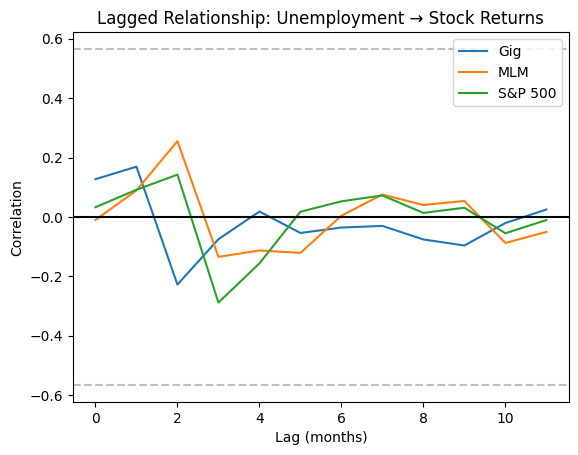

In [22]:
# plot lag relationships

lags = range(len(gig_ccf))

plt.plot(lags, gig_ccf, label='Gig')
plt.plot(lags, mlm_ccf, label='MLM')
plt.plot(lags, sp_ccf, label='S&P 500')


plt.axhline(0, color='black')
plt.xlabel("Lag (months)")
plt.ylabel("Correlation")
plt.title("Lagged Relationship: Unemployment → Stock Returns")
plt.legend()

# add confidence interval to reduce noise
n = len(gig_ccf)
ci = 1.96 / np.sqrt(n)
plt.axhline(ci, color='gray', linestyle='--', alpha=0.5, label='95% CI')
plt.axhline(-ci, color='gray', linestyle='--', alpha=0.5)

plt.show()

In [23]:
# run compute_ccf function to see lag relationships between inflation and returns

gig_CPI_ccf = compute_ccf(gig_ts['Inflation_change'], gig_ts['Return'])
mlm_CPI_ccf = compute_ccf(mlm_ts['Inflation_change'], mlm_ts['Return'])
sp_CPI_ccf  = compute_ccf(sp_ts['Inflation_change'], sp_ts['Return'])

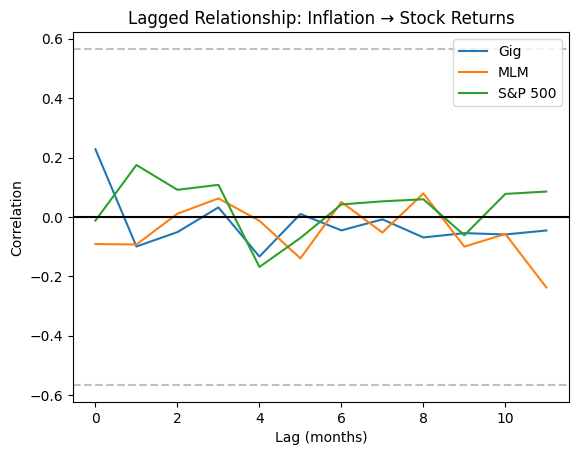

In [24]:
# plot lag relationships
lags = range(len(gig_CPI_ccf))

plt.plot(lags, gig_CPI_ccf, label='Gig')
plt.plot(lags, mlm_CPI_ccf, label='MLM')
plt.plot(lags, sp_CPI_ccf, label='S&P 500')

plt.axhline(0, color='black')
plt.xlabel("Lag (months)")
plt.ylabel("Correlation")
plt.title("Lagged Relationship: Inflation → Stock Returns")
plt.legend()

# add confidence interval to reduce noise
n = len(gig_ccf)
ci = 1.96 / np.sqrt(n)
plt.axhline(ci, color='gray', linestyle='--', alpha=0.5, label='95% CI')
plt.axhline(-ci, color='gray', linestyle='--', alpha=0.5)

plt.show()